# Quality assessment tutorial

[solarpy.org](https://www.solarpy.org).


## Get familiar with Google Colab

This notebook can be seamlessly run in Google Colab, a free, no-installation tool for running Python code from your web browser. 

Notebooks are organized by text and code "cells".  You can double-click a cell to start editing it.  To render a text cell or execute a code cell, hit shift+enter.

👉 In the code cell below, calculate ``16*42`` to explore how the notebook and Python work:

In [6]:
1+2

3

## Install pvlib & solarpy

In this tutorial we will be mainly using two Python packages:
- [pvlib](https://pvlib-python.readthedocs.io/): a community developed library for solar energy and radiation modeling
- [solarpy](https://www.solarpy.org): a library for working with solar resource data

Since these packages are not standard Python packages, we need to first install them in the Google Colab environment.

👉 *Action*: Execute the cell below and accept the terms.

In [ ]:
!pip install pvlib
!pip install git+https://github.com/assessingsolar/solarpy.git

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 19.4/19.4 MB 32.1 MB/s eta 0:00:00
  Cloning https://github.com/assessingsolar/solarpy.git to /tmp/pip-req-build-5cjhh71v
  Running command git clone --filter=blob:none --quiet https://github.com/assessingsolar/solarpy.git /tmp/pip-req-build-5cjhh71v
  Resolved https://github.com/assessingsolar/solarpy.git to commit 460d9db53b3d46bd5dd0fbf6a18ff37fad8f7b58
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Created wheel for solarpy: filename=solarpy-0.1.dev80+g460d9db53-py3-none-any.whl size=41695 sha256=3ba16e7ba42d510ada6e1c0e98b4a6ed34567d28e74340e9ead838c2e7f9c6ef
  Stored in directory: /tmp/pip-ephem-wheel-cache-gjs3_7y6/wheels/d7/c5/71/accd619465dfc2ff7908d2601ced89a44e8e377e0f90d1fe68
Successfully built solarpy


## Import packages

Before a Python package can be used it has to be imported. Importing loads the package and requires that the package is already installed (as done in the previous step).

In [2]:
import matplotlib.pyplot as plt  # library for plotting
import numpy as np  # library for numerical operations
import pandas as pd  # library for data manipulation
import pvlib  # library for solar energy calculations
import solarpy  # library for solar data processing and visualization


## Retrieve data from the BSRN

The easiest way to retrieve data from the BSRN is to use the Python function: [``pvlib.iotools.get_bsrn``](https://pvlib-python.readthedocs.io/en/stable/reference/generated/pvlib.iotools.get_bsrn.html).

The function has five required input parameters: station (3-letter code), start/end time, and username/password to the BSRN FTP server.

👉 *Action*: Change the ``station`` and ``start/end`` parameters in the below code block to retrieve data for the year and station of your choice.

In [ ]:
data, meta = pvlib.iotools.get_bsrn(
    station="CAB",  # modify this line
    start="YYYY-MM-DD",  # modify this line
    end="YYYY-MM-DD",  # modify this line
    username="bsrnftp",
    password="bsrn1",
)

data.head()  # print the first 5 lines of data

## Visualize data using heatmaps

When doing quality assessment of solar irradiance data one of the first steps should always be visualizing the data!

However, one year of 1-minute data is more than half a million data points, which results in overlapping data when using traditional line plots.

An effective way to visualize all individual data points of large datasets is to use heatmaps. For time series data, this can be done using intraday heatmaps, where the y-axis is the hour/minute of day, the x-axis is the date, and the color corresponds to the value of the data point. 

### Colormap
To make heatmaps even more effective, it is useful to define a custom colormap tailored to irradiance data: [``solarpy.plotting.irradiance_colormap_and_norm``](). The colormap we will use is split in two parts: solid color bands at low irradiance values and a visual continuous colormap for irradiance values above 2 W/m^2. The solid colorband are: red (<6 W/m2), orange (-6 to -2 W/m2), dark grey (-2 to 0 W/m2), and light grey (0, 2 W/m2). The purpose of these solid color bands is to provide a quick overview of thermal offsets and create a stark contrast between nighttime and daytime measurements.

👉 *Action*: Change the ``values`` parameter in the code cell below to visualize the ``"dni"`` measurements.

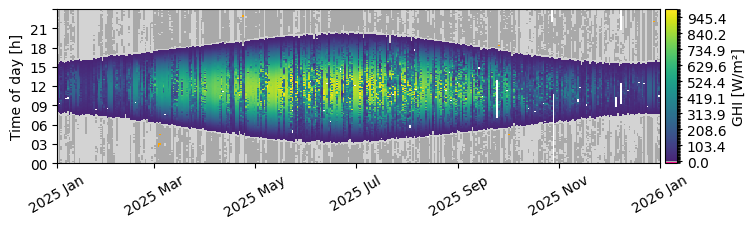

In [4]:
# Load custom colormap and norm
cmap, norm = solarpy.plotting.irradiance_colormap_and_norm(vmax=1000)

# Plot intraday heatmap
fig, ax = solarpy.plotting.plot_intraday_heatmap(
    time=data.index,
    values=data["ghi"],
    cmap=cmap,
    norm=norm,
    colorbar_label="GHI [W/m²]",
)

## Solar position

In this step, we will calculate the solar position for each timestamp, which is necessary to bin measurements by solar position and calculate GHI from DHI and DNI.

We will use the function [pvlib.solarposition.get_solarposition]() to calculate solar position. The function needs the timesteps (including timezone) and location of the station (latitude and longitude). The coordinates of the stations are included in the ``meta`` dictionary.

👉 *Action*: Run the cell below without modifying the code.

In [ ]:
solar_position = pvlib.solarposition.get_solarposition(
    time=data.index,
    latitude=meta["latitude"],
    longitude=meta["longitude"],
)

solar_position.head()  # show the first 5 lines

,apparent_zenith,zenith,apparent_elevation,elevation,azimuth,equation_of_time
2025-01-01 00:00:00+00:00,150.862861,150.862861,-60.862861,-60.862861,7.706269,-3.438820
2025-01-01 00:01:00+00:00,150.841531,150.841531,-60.841531,-60.841531,8.176545,-3.439149
2025-01-01 00:02:00+00:00,150.818952,150.818952,-60.818952,-60.818952,8.646252,-3.439478
2025-01-01 00:03:00+00:00,150.795125,150.795125,-60.795125,-60.795125,9.115359,-3.439807
2025-01-01 00:04:00+00:00,150.770054,150.770054,-60.770054,-60.770054,9.583837,-3.440135


## Horizon line

In locations with mountains and hills it is possible to estimate the local horizon line from topography data. THis



## Shading

Causes:
- Buildings
- Vegetation (trees)
- Mountains and hills
- Other instruments

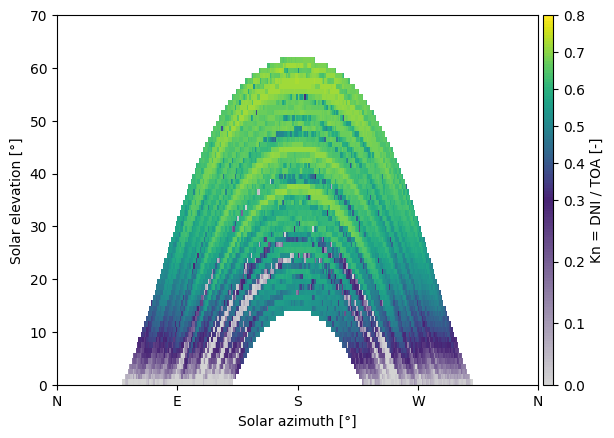

In [15]:
from matplotlib.colors import TwoSlopeNorm

dni_extra = pvlib.irradiance.get_extra_radiation(data.index)

fig, ax = solarpy.plotting.plot_shading_heatmap(
    value=data["dni"] / dni_extra,
    solar_azimuth=solar_position["azimuth"],
    solar_elevation=solar_position["elevation"],
    cmap=solarpy.plotting.two_part_colormap(),
    norm=TwoSlopeNorm(vmin=0, vcenter=0.3, vmax=0.8),
    colorbar_label="Kn = DNI / TOA [-]",
)